
Batch Gradient Descent:
MSE: 0.4126608642641093
R² Score: -0.23546878809728766

Linear Regression:
MSE: 0.4126674427356243
R² Score: -0.2354884834377815


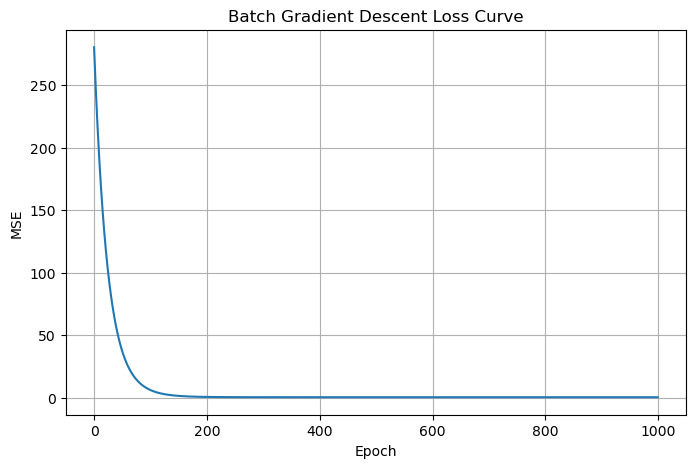


Batch GD Theta: [16.94225413  0.08364101  0.06142442]
Linear Regression Coefficients: [0.08364046 0.06141917]
Linear Regression Intercept: 16.942257596010805


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# 1. Input data manually
data_dict = {
    'Period': ['Sep 2014 - Aug 2015', 'Sep 2014 - Aug 2015', 'Sep 2015 - Jun 2016', 'Sep 2015 - Jun 2016',
               'Jul 2016 - Jun 2017', 'Jul 2016 - Jun 2017', 'Jul 2017 - Jun 2018', 'Jul 2017 - Jun 2018',
               'Jul 2018 - Jun 2019', 'Jul 2018 - Jun 2019', 'Jul 2019 - Jun 2020', 'Jul 2019 - Jun 2020',
               'Jul 2020 - Jun 2021', 'Jul 2020 - Jun 2021', 'Jul 2021 - Jun 2022', 'Jul 2021 - Jun 2022',
               'Jul 2022 - Mar 2023', 'Jul 2022 - Mar 2023'],
    'Treaty Type': ['Quota Share', '1st Surplus'] * 9,
    'Contribution': [9117769, 14494140, 14625614, 40058668, 13215455, 44156668, 17436180, 63647322,
                     15214887, 45415621, 49668119, 12250589, 35440352, 8005019, 42873091, 14769544,
                     24265332, 11716474],
    'Rebate': [1641198, 2608945, 2632611, 7210560, 2378782, 7948200, 2664465, 7364613, 2738680, 8174812,
               7946899, 1960094, 5670456, 1280803, 6859695, 2363127, 3882453, 1874636],
    'Paid Losses': [3537375, 7877921, 4690866, 28811280, 11460347, 55789226, 13691857, 85972350, 3613279,
                    22828848, 29313313, 28179923, 16240926, 4487660, 28783304, 1069548, 853986, 6764],
    'Outstanding Losses': [0, 0, 0, 0, 114800, 459201, 6448, 61105, 491037, 11429136, 2436396, 1279189,
                           6546306, 467243, 100584971, 130026469, 586373, 187500],
    'Incurred Losses': [3537375, 7877921, 4690866, 28811280, 11575147, 56248427, 13698305, 86033455, 4104316,
                        34257984, 31749709, 29459112, 22787232, 4954903, 129368275, 131096017, 1440359, 194264],
    'Loss Ratio (%)': [39, 54, 32, 72, 88, 127, 79, 135, 27, 75, 64, 240, 64, 62, 302, 888, 6, 2],
    'Profit Balance': [3939196, 4007274, 7302137, 4036828, -738474, -20039959, 1073410, -29750746,
                       8371891, 2982825, 9971511, -19168617, 6982664, 1769313, -93354879, -118689600,
                       18942520, 9647574],
    'Net Profit': [3939196, 4007274, 7302137, 4036828, -738474, -20039959, 1073410, -29750746,
                   8371891, 2982825, 9971511, -19168617, 6982664, 1769313, -93354879, -118689600,
                   18942520, 9647574],
    'Profit Ratio (%)': [43, 28, 50, 10, -6, -45, 6, -47, 55, 7, 20, -156, 20, 22, -218, -804, 78, 82]
}
data = pd.DataFrame(data_dict)

# 2. Drop 'Period' column
data = data.drop(columns=['Period'])

# 3. Identify numeric and categorical columns
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

# 4. Handle missing values in numeric columns with mean imputation
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

# 5. Handle categorical columns
if len(categorical_cols) > 0:
    le = LabelEncoder()
    for col in categorical_cols:
        data[col] = le.fit_transform(data[col])

# 6. Multicollinearity removal
corr_matrix = data[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
data = data.drop(columns=to_drop)
numeric_cols = [col for col in numeric_cols if col not in to_drop]

# 7. Apply log1p (handle negative/zero values)
data[numeric_cols] = data[numeric_cols].applymap(lambda x: np.log1p(x) if x > -1 else np.nan)
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

# 8. Split into features and target
target_column = numeric_cols[0]
X = data.drop(columns=[target_column])
y = data[target_column]

# 9. Normalize
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# 10. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 11. Batch Gradient Descent
class BatchGradientDescentRegressor:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.losses = []

    def fit(self, X, y):
        X = np.c_[np.ones((X.shape[0], 1)), X]
        self.theta = np.random.randn(X.shape[1])
        for epoch in range(self.epochs):
            gradients = -2/X.shape[0] * X.T.dot(y - X.dot(self.theta))
            self.theta -= self.learning_rate * gradients
            loss = np.mean((y - X.dot(self.theta))**2)
            self.losses.append(loss)

    def predict(self, X):
        X = np.c_[np.ones((X.shape[0], 1)), X]
        return X.dot(self.theta)

model = BatchGradientDescentRegressor()
model.fit(X_train.values, y_train.values)
y_pred_gd = model.predict(X_test.values)

# 12. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# 13. Evaluation
print("\nBatch Gradient Descent:")
print("MSE:", mean_squared_error(y_test, y_pred_gd))
print("R² Score:", r2_score(y_test, y_pred_gd))

print("\nLinear Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R² Score:", r2_score(y_test, y_pred_lr))

# 14. Loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(model.epochs), model.losses)
plt.title("Batch Gradient Descent Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

# 15. Model Parameters
print("\nBatch GD Theta:", model.theta)
print("Linear Regression Coefficients:", lr.coef_)
print("Linear Regression Intercept:", lr.intercept_)


In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# 1. Input data manually
data_dict = {
    'Period': ['Sep 2014 - Aug 2015', 'Sep 2014 - Aug 2015', 'Sep 2015 - Jun 2016', 'Sep 2015 - Jun 2016',
               'Jul 2016 - Jun 2017', 'Jul 2016 - Jun 2017', 'Jul 2017 - Jun 2018', 'Jul 2017 - Jun 2018',
               'Jul 2018 - Jun 2019', 'Jul 2018 - Jun 2019', 'Jul 2019 - Jun 2020', 'Jul 2019 - Jun 2020',
               'Jul 2020 - Jun 2021', 'Jul 2020 - Jun 2021', 'Jul 2021 - Jun 2022', 'Jul 2021 - Jun 2022',
               'Jul 2022 - Mar 2023', 'Jul 2022 - Mar 2023'],
    'Treaty Type': ['Quota Share', '1st Surplus'] * 9,
    'Contribution': [9117769, 14494140, 14625614, 40058668, 13215455, 44156668, 17436180, 63647322,
                     15214887, 45415621, 49668119, 12250589, 35440352, 8005019, 42873091, 14769544,
                     24265332, 11716474],
    'Rebate': [1641198, 2608945, 2632611, 7210560, 2378782, 7948200, 2664465, 7364613, 2738680, 8174812,
               7946899, 1960094, 5670456, 1280803, 6859695, 2363127, 3882453, 1874636],
    'Paid Losses': [3537375, 7877921, 4690866, 28811280, 11460347, 55789226, 13691857, 85972350, 3613279,
                    22828848, 29313313, 28179923, 16240926, 4487660, 28783304, 1069548, 853986, 6764],
    'Outstanding Losses': [0, 0, 0, 0, 114800, 459201, 6448, 61105, 491037, 11429136, 2436396, 1279189,
                           6546306, 467243, 100584971, 130026469, 586373, 187500],
    'Incurred Losses': [3537375, 7877921, 4690866, 28811280, 11575147, 56248427, 13698305, 86033455, 4104316,
                        34257984, 31749709, 29459112, 22787232, 4954903, 129368275, 131096017, 1440359, 194264],
    'Loss Ratio (%)': [39, 54, 32, 72, 88, 127, 79, 135, 27, 75, 64, 240, 64, 62, 302, 888, 6, 2],
    'Profit Balance': [3939196, 4007274, 7302137, 4036828, -738474, -20039959, 1073410, -29750746,
                       8371891, 2982825, 9971511, -19168617, 6982664, 1769313, -93354879, -118689600,
                       18942520, 9647574],
    'Net Profit': [3939196, 4007274, 7302137, 4036828, -738474, -20039959, 1073410, -29750746,
                   8371891, 2982825, 9971511, -19168617, 6982664, 1769313, -93354879, -118689600,
                   18942520, 9647574],
    'Profit Ratio (%)': [43, 28, 50, 10, -6, -45, 6, -47, 55, 7, 20, -156, 20, 22, -218, -804, 78, 82]
}
data = pd.DataFrame(data_dict)
print(data)

                 Period  Treaty Type  Contribution   Rebate  Paid Losses  \
0   Sep 2014 - Aug 2015  Quota Share       9117769  1641198      3537375   
1   Sep 2014 - Aug 2015  1st Surplus      14494140  2608945      7877921   
2   Sep 2015 - Jun 2016  Quota Share      14625614  2632611      4690866   
3   Sep 2015 - Jun 2016  1st Surplus      40058668  7210560     28811280   
4   Jul 2016 - Jun 2017  Quota Share      13215455  2378782     11460347   
5   Jul 2016 - Jun 2017  1st Surplus      44156668  7948200     55789226   
6   Jul 2017 - Jun 2018  Quota Share      17436180  2664465     13691857   
7   Jul 2017 - Jun 2018  1st Surplus      63647322  7364613     85972350   
8   Jul 2018 - Jun 2019  Quota Share      15214887  2738680      3613279   
9   Jul 2018 - Jun 2019  1st Surplus      45415621  8174812     22828848   
10  Jul 2019 - Jun 2020  Quota Share      49668119  7946899     29313313   
11  Jul 2019 - Jun 2020  1st Surplus      12250589  1960094     28179923   
12  Jul 2020

In [10]:
# Identify numeric and categorical columns
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

# Show the output
print("Numeric Columns:")
print(numeric_cols)

print("\nCategorical Columns:")
print(categorical_cols)


Numeric Columns:
['Contribution', 'Rebate', 'Paid Losses', 'Outstanding Losses', 'Incurred Losses', 'Loss Ratio (%)', 'Profit Balance', 'Net Profit', 'Profit Ratio (%)']

Categorical Columns:
['Treaty Type']


In [12]:
# 4. Handle missing values in numeric columns with mean imputation
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())
print(data[numeric_cols])



    Contribution   Rebate  Paid Losses  Outstanding Losses  Incurred Losses  \
0        9117769  1641198      3537375                   0          3537375   
1       14494140  2608945      7877921                   0          7877921   
2       14625614  2632611      4690866                   0          4690866   
3       40058668  7210560     28811280                   0         28811280   
4       13215455  2378782     11460347              114800         11575147   
5       44156668  7948200     55789226              459201         56248427   
6       17436180  2664465     13691857                6448         13698305   
7       63647322  7364613     85972350               61105         86033455   
8       15214887  2738680      3613279              491037          4104316   
9       45415621  8174812     22828848            11429136         34257984   
10      49668119  7946899     29313313             2436396         31749709   
11      12250589  1960094     28179923             1

In [13]:
# 5. Handle categorical columns
if len(categorical_cols) > 0:
    le = LabelEncoder()
    for col in categorical_cols:
        data[col] = le.fit_transform(data[col])

# Show the output (transformed DataFrame or categorical columns)
print("Transformed DataFrame:")
print(data.head())  # Display the first few rows to check the changes

print("\nTransformed Categorical Columns:")
print(categorical_cols)  # Display the list of categorical columns



Transformed DataFrame:
   Treaty Type  Contribution   Rebate  Paid Losses  Outstanding Losses  \
0            1       9117769  1641198      3537375                   0   
1            0      14494140  2608945      7877921                   0   
2            1      14625614  2632611      4690866                   0   
3            0      40058668  7210560     28811280                   0   
4            1      13215455  2378782     11460347              114800   

   Incurred Losses  Loss Ratio (%)  Profit Balance  Net Profit  \
0          3537375              39         3939196     3939196   
1          7877921              54         4007274     4007274   
2          4690866              32         7302137     7302137   
3         28811280              72         4036828     4036828   
4         11575147              88         -738474     -738474   

   Profit Ratio (%)  
0                43  
1                28  
2                50  
3                10  
4                -6  

Tr

In [15]:
import numpy as np

# 6. Multicollinearity removal
corr_matrix = data[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
data = data.drop(columns=to_drop)
numeric_cols = [col for col in numeric_cols if col not in to_drop]

# Show the output of multicollinearity removal
print("Columns dropped due to multicollinearity:")
print(to_drop)

# Show the DataFrame after dropping highly correlated columns
print("\nData after multicollinearity removal:")
print(data.head())  # Display the first few rows of the data after dropping columns

# 7. Apply log1p (handle negative/zero values)
data[numeric_cols] = data[numeric_cols].applymap(lambda x: np.log1p(x) if x > -1 else np.nan)
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

# Show the output after applying log1p and filling missing values
print("\nData after applying log1p and filling missing values:")
print(data.head())  # Display the first few rows of the data after transformation


Columns dropped due to multicollinearity:
['Rebate', 'Paid Losses', 'Incurred Losses', 'Loss Ratio (%)', 'Profit Balance', 'Net Profit', 'Profit Ratio (%)']

Data after multicollinearity removal:
   Treaty Type  Contribution  Outstanding Losses
0            1       9117769                   0
1            0      14494140                   0
2            1      14625614                   0
3            0      40058668                   0
4            1      13215455              114800

Data after applying log1p and filling missing values:
   Treaty Type  Contribution  Outstanding Losses
0            1     16.025736            0.000000
1            0     16.489255            0.000000
2            1     16.498285            0.000000
3            0     17.505856            0.000000
4            1     16.396898           11.650955


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 8. Split into features and target
target_column = numeric_cols[0]
X = data.drop(columns=[target_column])
y = data[target_column]

# Show the output after splitting into features and target
print("Features (X) and Target (y) split:")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# 9. Normalize
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Show the output after normalization
print("\nNormalized Features (X_scaled) preview:")
print(X_scaled.head())  # Display the first few rows of normalized features

# 10. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Show the output after train-test split
print("\nTrain-Test Split:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Features (X) and Target (y) split:
Features shape: (18, 2)
Target shape: (18,)

Normalized Features (X_scaled) preview:
   Treaty Type  Outstanding Losses
0          1.0           -1.733887
1         -1.0           -1.733887
2          1.0           -1.733887
3         -1.0           -1.733887
4          1.0            0.141576

Train-Test Split:
X_train shape: (14, 2)
X_test shape: (4, 2)
y_train shape: (14,)
y_test shape: (4,)


In [20]:
import numpy as np

# 11. Batch Gradient Descent
class BatchGradientDescentRegressor:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.losses = []

    def fit(self, X, y):
        X = np.c_[np.ones((X.shape[0], 1)), X]  # Add intercept term (bias)
        self.theta = np.random.randn(X.shape[1])  # Initialize theta randomly
        for epoch in range(self.epochs):
            gradients = -2/X.shape[0] * X.T.dot(y - X.dot(self.theta))
            self.theta -= self.learning_rate * gradients  # Update theta
            loss = np.mean((y - X.dot(self.theta))**2)  # Compute the loss
            self.losses.append(loss)  # Store the loss

    def predict(self, X):
        X = np.c_[np.ones((X.shape[0], 1)), X]  # Add intercept term (bias)
        return X.dot(self.theta)  # Predict using the model

# Train the model
model = BatchGradientDescentRegressor()
model.fit(X_train.values, y_train.values)

# Make predictions
y_pred_gd = model.predict(X_test.values)

# Show the output

# Display the loss over epochs
print("Loss over epochs:")
print(model.losses[:10])  # Show the first 10 loss values to avoid printing too many

# Display the final model parameters (theta)
print("\nFinal model parameters (theta):")
print(model.theta)

# Display a preview of predicted vs actual values
print("\nPredicted vs Actual values (for the first 5 test samples):")
comparison_df = pd.DataFrame({'Actual': y_test.values[:5], 'Predicted': y_pred_gd[:5]})
print(comparison_df)


Loss over epochs:
[288.9075279777279, 277.0056211460605, 265.60760816395475, 254.69176228250055, 244.2373052718514, 234.2243656683543, 224.63393886960378, 215.4478489953423, 206.6487124357839, 198.21990301242946]

Final model parameters (theta):
[16.94225415  0.083641    0.06142438]

Predicted vs Actual values (for the first 5 test samples):
      Actual  Predicted
0  16.025736  16.919392
1  16.489255  16.752110
2  16.537785  17.048961
3  17.603255  16.881016



Batch Gradient Descent:
MSE: 0.4126609100211906
R² Score: -0.23546892508979345

Linear Regression:
MSE: 0.4126674427356243
R² Score: -0.2354884834377815


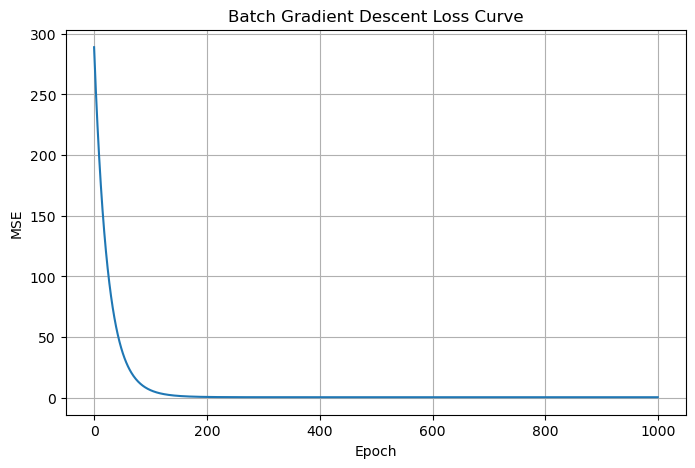


Batch GD Theta: [16.94225415  0.083641    0.06142438]
Linear Regression Coefficients: [0.08364046 0.06141917]
Linear Regression Intercept: 16.942257596010805


In [21]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 12. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# 13. Evaluation
print("\nBatch Gradient Descent:")
print("MSE:", mean_squared_error(y_test, y_pred_gd))
print("R² Score:", r2_score(y_test, y_pred_gd))

print("\nLinear Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R² Score:", r2_score(y_test, y_pred_lr))

# 14. Loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(model.epochs), model.losses)
plt.title("Batch Gradient Descent Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

# 15. Model Parameters
print("\nBatch GD Theta:", model.theta)
print("Linear Regression Coefficients:", lr.coef_)
print("Linear Regression Intercept:", lr.intercept_)
